# Portfolio Optimization Engine
## Mean-Variance | Black-Litterman | Risk Parity

**Author:** Benicio Mazzoldi
**Environment:** Google Colab

This notebook implements and compares three institutional portfolio construction
methodologies on a multi-asset ETF universe, with a walk-forward out-of-sample
backtest, transaction costs, and a full performance tearsheet.

| Method | Core Idea | Weakness Addressed |
|---|---|---|
| Mean-Variance (Markowitz) | Maximize return per unit of risk | Baseline; unstable to input errors |
| Black-Litterman | Blend market equilibrium with investor views | Fixes MV's input-sensitivity problem |
| Risk Parity | Equalize risk contribution across assets | Removes return forecasting entirely |

In [1]:
# ============================================================
# SECTION 1 | ENVIRONMENT SETUP
# ============================================================
# Install dependencies (Colab-safe: quiet, pinned where stability matters)
!pip install -q yfinance scikit-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

RNG = np.random.default_rng(42)
print("Environment ready.")

Environment ready.


In [2]:
# ============================================================
# SECTION 2 | CONFIGURATION
# ============================================================
# Multi-asset universe: broad, liquid ETF proxies for major asset classes.
UNIVERSE = {
    "SPY": "US Large Cap Equity",
    "IWM": "US Small Cap Equity",
    "EFA": "Developed Intl Equity",
    "EEM": "Emerging Mkt Equity",
    "AGG": "US Aggregate Bonds",
    "TLT": "Long-Term Treasuries",
    "LQD": "IG Corporate Bonds",
    "GLD": "Gold",
    "DBC": "Broad Commodities",
    "VNQ": "US REITs",
}
TICKERS = list(UNIVERSE.keys())

START_DATE       = "2007-01-01"   # spans GFC, 2020, 2022 rate shock
END_DATE         = None            # None = today
RISK_FREE_TICKER = "^IRX"          # 13-week T-bill yield (annualized %, /100)

# Backtest parameters
LOOKBACK_MONTHS   = 60             # 5y estimation window
REBALANCE_FREQ    = "QE"           # quarterly rebalance
TCOST_BPS         = 10             # one-way transaction cost, basis points
LONG_ONLY         = True
MAX_WEIGHT        = 0.40           # single-asset concentration cap

# Black-Litterman parameters
BL_TAU   = 0.05                    # uncertainty scalar on the prior
BL_DELTA = 2.5                     # market risk-aversion coefficient

print(f"Universe: {len(TICKERS)} assets | Rebalance: {REBALANCE_FREQ} | "
      f"Lookback: {LOOKBACK_MONTHS}m | t-costs: {TCOST_BPS}bps")

Universe: 10 assets | Rebalance: QE | Lookback: 60m | t-costs: 10bps


In [3]:
# ============================================================
# SECTION 3 | DATA COLLECTION PIPELINE
# ============================================================
def fetch_prices(tickers: list[str], start: str, end=None) -> pd.DataFrame:
    """Download adjusted close prices with basic integrity checks."""
    try:
        raw = yf.download(tickers, start=start, end=end,
                          auto_adjust=True, progress=False)
        px = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw[["Close"]]
        px = px[tickers].sort_index()
    except Exception as e:
        raise RuntimeError(f"Price download failed: {e}") from e

    # Integrity checks
    if px.empty:
        raise ValueError("No price data returned - check tickers/dates.")
    missing = px.columns[px.isna().mean() > 0.10].tolist()
    if missing:
        print(f"WARNING: >10% missing data for {missing}")
    return px

def fetch_risk_free(start: str, end=None) -> pd.Series:
    """13-week T-bill yield as daily risk-free rate (decimal, annualized)."""
    try:
        rf = yf.download(RISK_FREE_TICKER, start=start, end=end,
                         auto_adjust=True, progress=False)["Close"]
        if isinstance(rf, pd.DataFrame):
            rf = rf.iloc[:, 0]
        return (rf / 100.0).rename("rf")
    except Exception:
        print("WARNING: risk-free fetch failed; using flat 2% assumption.")
        return pd.Series(dtype=float)

prices = fetch_prices(TICKERS, START_DATE, END_DATE)
rf_series = fetch_risk_free(START_DATE, END_DATE)

print(f"Prices: {prices.shape[0]} days x {prices.shape[1]} assets "
      f"({prices.index[0].date()} to {prices.index[-1].date()})")
prices.tail(3)

Prices: 4918 days x 10 assets (2007-01-03 to 2026-07-22)


Ticker,SPY,IWM,EFA,EEM,AGG,TLT,LQD,GLD,DBC,VNQ
Date,,,,,,,,,,
2026-07-20,742.090027,292.309998,102.570000,63.560001,97.949997,83.889999,107.150002,367.600006,29.139999,99.480003
2026-07-21,748.280029,296.540009,104.059998,65.339996,97.739998,83.660004,106.849998,374.809998,29.570000,99.519997
2026-07-22,747.409973,293.790009,104.250000,64.989998,97.580002,83.440002,106.669998,379.119995,29.860001,99.019997


In [4]:
# ============================================================
# SECTION 4 | DATA CLEANING & FEATURE ENGINEERING
# ============================================================
# Forward-fill short gaps (holidays/halts), drop rows before all assets exist.
prices_clean = prices.ffill(limit=5).dropna()

# Daily simple returns for backtesting; monthly returns for estimation.
ret_daily   = prices_clean.pct_change().dropna()
ret_monthly = prices_clean.resample("ME").last().pct_change().dropna()

# Align a daily risk-free series (annualized -> daily)
if len(rf_series) > 0:
    rf_daily = (rf_series.reindex(ret_daily.index).ffill() / 252).fillna(0.02 / 252)
else:
    rf_daily = pd.Series(0.02 / 252, index=ret_daily.index)

# Basic sanity: flag absurd daily moves (bad ticks)
bad = (ret_daily.abs() > 0.5).sum().sum()
print(f"Cleaned. Daily obs: {len(ret_daily)} | Monthly obs: {len(ret_monthly)} | "
      f"Suspect ticks (>50% daily move): {bad}")

Cleaned. Daily obs: 4917 | Monthly obs: 234 | Suspect ticks (>50% daily move): 0


In [5]:
# ============================================================
# SECTION 5 | ESTIMATION LAYER
# ============================================================
ANNUALIZE = 12  # monthly estimation basis

def estimate_inputs(monthly_rets: pd.DataFrame):
    """Expected returns (historical mean) + Ledoit-Wolf shrunk covariance.

    Shrinkage pulls the sample covariance toward a structured target,
    dramatically stabilizing downstream optimization (the classic fix for
    Markowitz 'error maximization').
    """
    mu = monthly_rets.mean().values * ANNUALIZE
    lw = LedoitWolf().fit(monthly_rets.values)
    sigma = lw.covariance_ * ANNUALIZE
    return mu, sigma, lw.shrinkage_

mu_full, sigma_full, shrink = estimate_inputs(ret_monthly)
vol_full = np.sqrt(np.diag(sigma_full))

summary = pd.DataFrame({
    "Asset Class": [UNIVERSE[t] for t in TICKERS],
    "Ann. Return": mu_full,
    "Ann. Vol": vol_full,
}, index=TICKERS)
print(f"Ledoit-Wolf shrinkage intensity: {shrink:.2%}")
summary.style.format({"Ann. Return": "{:.1%}", "Ann. Vol": "{:.1%}"})

Ledoit-Wolf shrinkage intensity: 4.52%


,Asset Class,Ann. Return,Ann. Vol
SPY,US Large Cap Equity,11.5%,15.5%
IWM,US Small Cap Equity,10.2%,20.2%
EFA,Developed Intl Equity,6.2%,17.2%
EEM,Emerging Mkt Equity,7.0%,20.8%
AGG,US Aggregate Bonds,3.1%,5.7%
TLT,Long-Term Treasuries,3.8%,14.1%
LQD,IG Corporate Bonds,4.3%,8.8%
GLD,Gold,10.6%,17.3%
DBC,Broad Commodities,4.0%,18.9%
VNQ,US REITs,7.5%,21.9%


In [6]:
# ============================================================
# SECTION 6 | CORE MODEL 1: MEAN-VARIANCE OPTIMIZATION
# ============================================================
def _constraints(n: int):
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
    lb = 0.0 if LONG_ONLY else -MAX_WEIGHT
    bounds = [(lb, MAX_WEIGHT)] * n
    return cons, bounds

def port_stats(w, mu, sigma, rf=0.0):
    r = w @ mu
    v = np.sqrt(w @ sigma @ w)
    return r, v, (r - rf) / v if v > 0 else 0.0

def max_sharpe(mu, sigma, rf=0.0):
    n = len(mu)
    cons, bounds = _constraints(n)
    obj = lambda w: -port_stats(w, mu, sigma, rf)[2]
    res = minimize(obj, np.ones(n) / n, method="SLSQP",
                   bounds=bounds, constraints=cons,
                   options={"maxiter": 1000, "ftol": 1e-10})
    if not res.success:
        print(f"WARNING: max-Sharpe solver: {res.message}")
    return res.x

def min_vol(mu, sigma):
    n = len(mu)
    cons, bounds = _constraints(n)
    res = minimize(lambda w: w @ sigma @ w, np.ones(n) / n, method="SLSQP",
                   bounds=bounds, constraints=cons,
                   options={"maxiter": 1000, "ftol": 1e-12})
    return res.x

def efficient_frontier(mu, sigma, n_points=40):
    """Sweep target returns between min-vol and max-return portfolios."""
    n = len(mu)
    w_mv = min_vol(mu, sigma)
    r_lo = w_mv @ mu
    r_hi = mu.max() * 0.999
    frontier = []
    for r_target in np.linspace(r_lo, r_hi, n_points):
        cons, bounds = _constraints(n)
        cons = cons + [{"type": "eq", "fun": lambda w, rt=r_target: w @ mu - rt}]
        res = minimize(lambda w: w @ sigma @ w, np.ones(n) / n, method="SLSQP",
                       bounds=bounds, constraints=cons,
                       options={"maxiter": 1000})
        if res.success:
            r, v, _ = port_stats(res.x, mu, sigma)
            frontier.append((v, r))
    return np.array(frontier)

rf_ann = float(rf_daily.mean() * 252)
w_msr = max_sharpe(mu_full, sigma_full, rf_ann)
w_gmv = min_vol(mu_full, sigma_full)
frontier = efficient_frontier(mu_full, sigma_full)

r_msr, v_msr, s_msr = port_stats(w_msr, mu_full, sigma_full, rf_ann)
print(f"Max-Sharpe portfolio | ret {r_msr:.1%} | vol {v_msr:.1%} | Sharpe {s_msr:.2f}")

Max-Sharpe portfolio | ret 8.9% | vol 9.3% | Sharpe 0.80


In [7]:
# ============================================================
# SECTION 7 | CORE MODEL 2: BLACK-LITTERMAN
# ============================================================
def market_cap_weights(tickers: list[str]) -> np.ndarray:
    """Market-cap weights for the equilibrium prior. AUM used as a pragmatic
    proxy for ETF universes; falls back to equal weight on failure."""
    caps = {}
    for t in tickers:
        try:
            info = yf.Ticker(t).info
            caps[t] = info.get("totalAssets") or info.get("marketCap") or np.nan
        except Exception:
            caps[t] = np.nan
    s = pd.Series(caps)
    if s.isna().all():
        print("WARNING: no cap data; using equal weights for prior.")
        return np.ones(len(tickers)) / len(tickers)
    s = s.fillna(s.median())
    return (s / s.sum()).values

def black_litterman(sigma, w_mkt, P, Q, tau=BL_TAU, delta=BL_DELTA, omega=None):
    """Posterior expected returns blending equilibrium with investor views.

    pi    : implied equilibrium excess returns  = delta * Sigma * w_mkt
    Omega : view uncertainty (default: diag(tau * P Sigma P'))
    """
    pi = delta * sigma @ w_mkt
    if omega is None:
        omega = np.diag(np.diag(tau * P @ sigma @ P.T))
    ts_inv = np.linalg.inv(tau * sigma)
    om_inv = np.linalg.inv(omega)
    post_cov = np.linalg.inv(ts_inv + P.T @ om_inv @ P)
    mu_bl = post_cov @ (ts_inv @ pi + P.T @ om_inv @ Q)
    return mu_bl, pi

w_mkt = market_cap_weights(TICKERS)

# --- Investor views (edit these - this is the whole point of BL) ----------
# View 1 (absolute): US large caps return 7% annually
# View 2 (relative): EM equities outperform developed intl by 2%
# View 3 (absolute): long treasuries return 3%
idx = {t: i for i, t in enumerate(TICKERS)}
P = np.zeros((2, len(TICKERS)))
Q = np.zeros(2)
P[0, idx["EEM"]] = 1.0; P[0, idx["EFA"]] = -1.0; Q[0] = 0.01   # mild: EM edges developed intl
P[1, idx["TLT"]] = 1.0;                          Q[1] = 0.10   # aggressive: rates fall, long bonds surge

mu_bl, pi_eq = black_litterman(sigma_full, w_mkt, P, Q)
w_bl = max_sharpe(mu_bl, sigma_full, rf_ann)

compare = pd.DataFrame({
    "Equilibrium (prior)": pi_eq,
    "Historical mean": mu_full,
    "Black-Litterman (posterior)": mu_bl,
}, index=TICKERS)
compare.style.format("{:.1%}")

,Equilibrium (prior),Historical mean,Black-Litterman (posterior)
SPY,4.6%,11.5%,4.2%
IWM,5.4%,10.2%,4.5%
EFA,4.6%,6.2%,4.4%
EEM,5.1%,7.0%,5.0%
AGG,0.6%,3.1%,1.8%
TLT,0.2%,3.8%,5.1%
LQD,1.4%,4.3%,3.0%
GLD,1.3%,10.6%,3.0%
DBC,2.6%,4.0%,0.7%
VNQ,5.3%,7.5%,6.4%


In [8]:
# ============================================================
# SECTION 8 | CORE MODEL 3: RISK PARITY (EQUAL RISK CONTRIBUTION)
# ============================================================
def risk_contributions(w, sigma):
    """Each asset's share of total portfolio volatility."""
    port_vol = np.sqrt(w @ sigma @ w)
    mrc = sigma @ w / port_vol          # marginal risk contribution
    return w * mrc                       # total risk contribution

def risk_parity(sigma):
    """Solve for weights where every asset contributes equal risk."""
    n = sigma.shape[0]
    target = 1.0 / n

    def obj(w):
        rc = risk_contributions(w, sigma)
        rc_share = rc / rc.sum()
        return np.sum((rc_share - target) ** 2)

    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
    bounds = [(1e-4, MAX_WEIGHT)] * n
    res = minimize(obj, np.ones(n) / n, method="SLSQP",
                   bounds=bounds, constraints=cons,
                   options={"maxiter": 2000, "ftol": 1e-14})
    return res.x

w_rp = risk_parity(sigma_full)
rc = risk_contributions(w_rp, sigma_full)
print("Risk parity - risk contribution share per asset (should be ~equal):")
print(pd.Series(rc / rc.sum(), index=TICKERS).round(3).to_string())

Risk parity - risk contribution share per asset (should be ~equal):
SPY    0.1
IWM    0.1
EFA    0.1
EEM    0.1
AGG    0.1
TLT    0.1
LQD    0.1
GLD    0.1
DBC    0.1
VNQ    0.1


In [9]:
# ============================================================
# SECTION 9 | WALK-FORWARD OUT-OF-SAMPLE BACKTEST
# ============================================================
def backtest(method: str, monthly_rets: pd.DataFrame,
             daily_rets: pd.DataFrame, rf_ann_avg: float):
    """Quarterly-rebalanced walk-forward backtest.

    At each rebalance date, estimate inputs on the trailing LOOKBACK window
    ONLY (no look-ahead), solve for weights, then hold until next rebalance.
    Transaction costs charged on turnover.
    """
    rebal_dates = daily_rets.resample(REBALANCE_FREQ).last().index
    rebal_dates = [d for d in rebal_dates if d in daily_rets.index or True]

    weights_hist, port_rets = {}, []
    w_prev = None

    for i, d in enumerate(rebal_dates[:-1]):
        est_window = monthly_rets.loc[:d].tail(LOOKBACK_MONTHS)
        if len(est_window) < LOOKBACK_MONTHS:
            continue
        mu, sigma, _ = estimate_inputs(est_window)

        try:
            if method == "mean_variance":
                w = max_sharpe(mu, sigma, rf_ann_avg)
            elif method == "black_litterman":
                mu_post, _ = black_litterman(sigma, w_mkt, P, Q)
                w = max_sharpe(mu_post, sigma, rf_ann_avg)
            elif method == "risk_parity":
                w = risk_parity(sigma)
            elif method == "equal_weight":
                w = np.ones(len(TICKERS)) / len(TICKERS)
            else:
                raise ValueError(method)
        except Exception as e:
            print(f"{method} solver failed at {d.date()}: {e}; holding prior weights")
            w = w_prev if w_prev is not None else np.ones(len(TICKERS)) / len(TICKERS)

        # Transaction cost on turnover (one-way)
        turnover = np.abs(w - w_prev).sum() if w_prev is not None else np.abs(w).sum()
        tcost = turnover * TCOST_BPS / 1e4

        hold = daily_rets.loc[d:rebal_dates[i + 1]].iloc[1:]
        if hold.empty:
            continue
        pr = hold.values @ w
        pr[0] -= tcost                      # charge costs on rebalance day
        port_rets.append(pd.Series(pr, index=hold.index))
        weights_hist[d] = w
        w_prev = w

    rets = pd.concat(port_rets).sort_index()
    rets = rets[~rets.index.duplicated()]
    wdf = pd.DataFrame(weights_hist, index=TICKERS).T
    return rets, wdf

STRATEGIES = ["mean_variance", "black_litterman", "risk_parity", "equal_weight"]
results, weight_paths = {}, {}
for s in STRATEGIES:
    results[s], weight_paths[s] = backtest(s, ret_monthly, ret_daily, rf_ann)
    print(f"Backtest complete: {s:16s} ({len(results[s])} days)")

Backtest complete: mean_variance    (3578 days)
Backtest complete: black_litterman  (3578 days)
Backtest complete: risk_parity      (3578 days)
Backtest complete: equal_weight     (3578 days)


In [10]:
# ============================================================
# SECTION 10 | PERFORMANCE METRICS
# ============================================================
def perf_metrics(rets: pd.Series, rf_d: pd.Series) -> dict:
    rf_al = rf_d.reindex(rets.index).ffill().fillna(0)
    excess = rets - rf_al
    ann_ret = (1 + rets).prod() ** (252 / len(rets)) - 1
    ann_vol = rets.std() * np.sqrt(252)
    sharpe  = excess.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0
    downside = rets[rets < 0].std() * np.sqrt(252)
    sortino = excess.mean() * 252 / downside if downside > 0 else 0
    curve = (1 + rets).cumprod()
    dd = curve / curve.cummax() - 1
    max_dd = dd.min()
    calmar = ann_ret / abs(max_dd) if max_dd < 0 else np.nan
    var95 = np.percentile(rets, 5)
    return {"Ann. Return": ann_ret, "Ann. Vol": ann_vol, "Sharpe": sharpe,
            "Sortino": sortino, "Max Drawdown": max_dd, "Calmar": calmar,
            "Daily VaR 95%": var95}

def avg_turnover(wdf: pd.DataFrame) -> float:
    return wdf.diff().abs().sum(axis=1).mean()

metrics = pd.DataFrame({s: perf_metrics(results[s], rf_daily) for s in STRATEGIES}).T
metrics["Avg Turnover/Rebal"] = [avg_turnover(weight_paths[s]) for s in STRATEGIES]
metrics.index = ["Mean-Variance", "Black-Litterman", "Risk Parity", "Equal Weight"]
metrics.style.format({
    "Ann. Return": "{:.1%}", "Ann. Vol": "{:.1%}", "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}", "Max Drawdown": "{:.1%}", "Calmar": "{:.2f}",
    "Daily VaR 95%": "{:.2%}", "Avg Turnover/Rebal": "{:.1%}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn")

,Ann. Return,Ann. Vol,Sharpe,Sortino,Max Drawdown,Calmar,Daily VaR 95%,Avg Turnover/Rebal
Mean-Variance,8.6%,9.9%,0.71,0.88,-21.8%,0.39,-0.90%,19.6%
Black-Litterman,6.7%,10.2%,0.52,0.68,-26.2%,0.25,-1.04%,7.3%
Risk Parity,5.7%,7.8%,0.53,0.66,-21.2%,0.27,-0.73%,4.4%
Equal Weight,6.7%,10.0%,0.54,0.67,-22.9%,0.29,-0.91%,0.0%


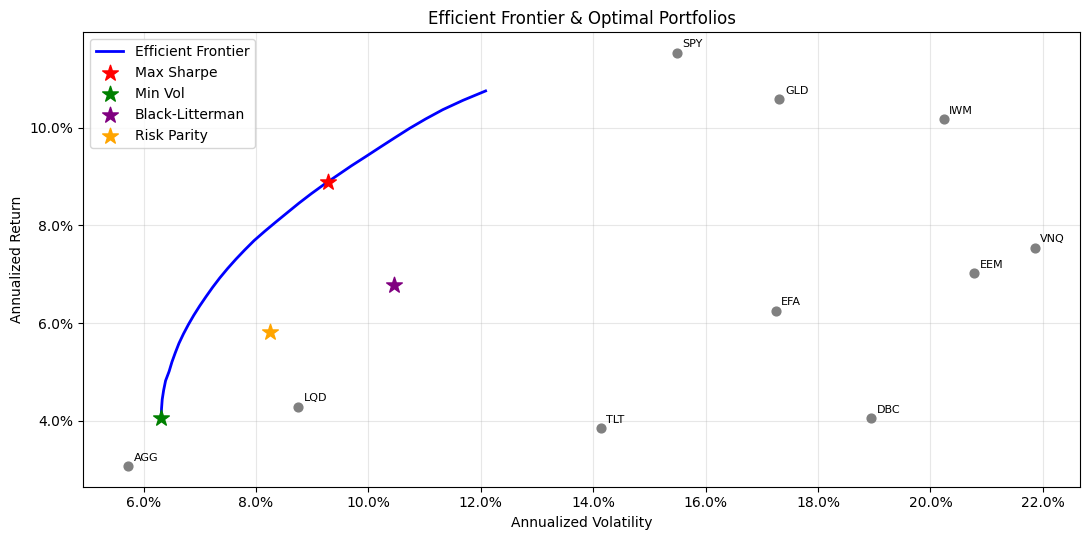

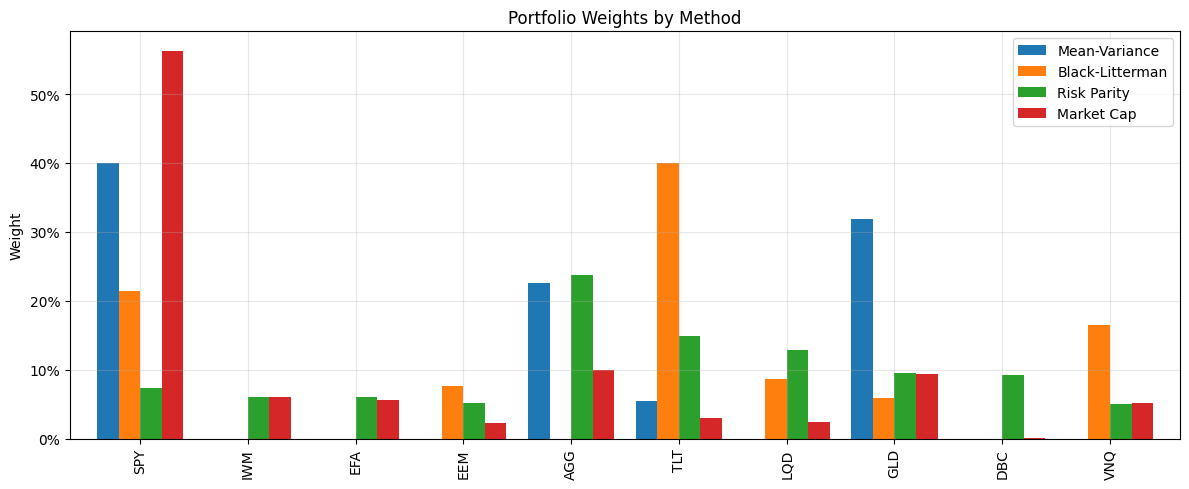

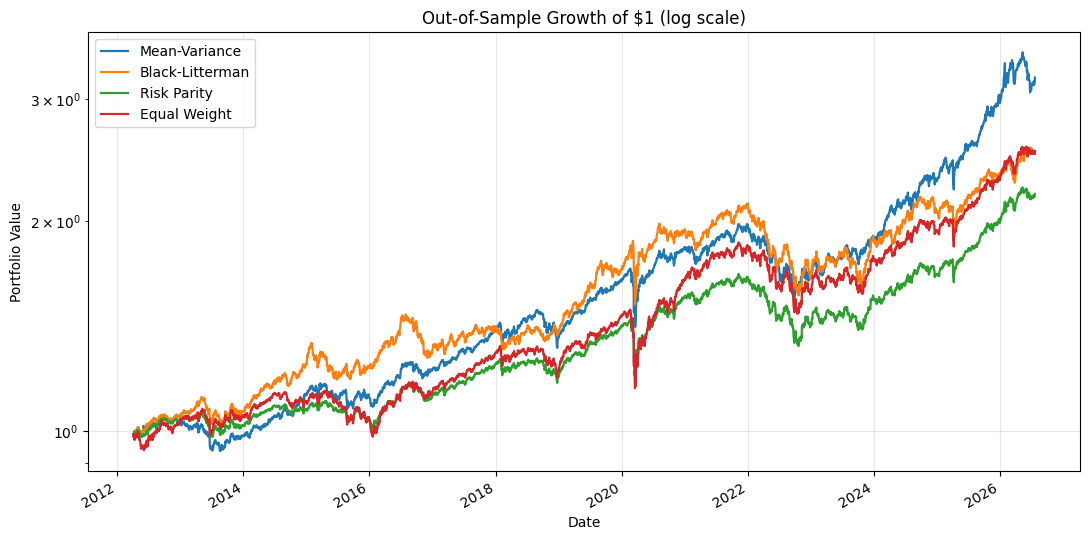

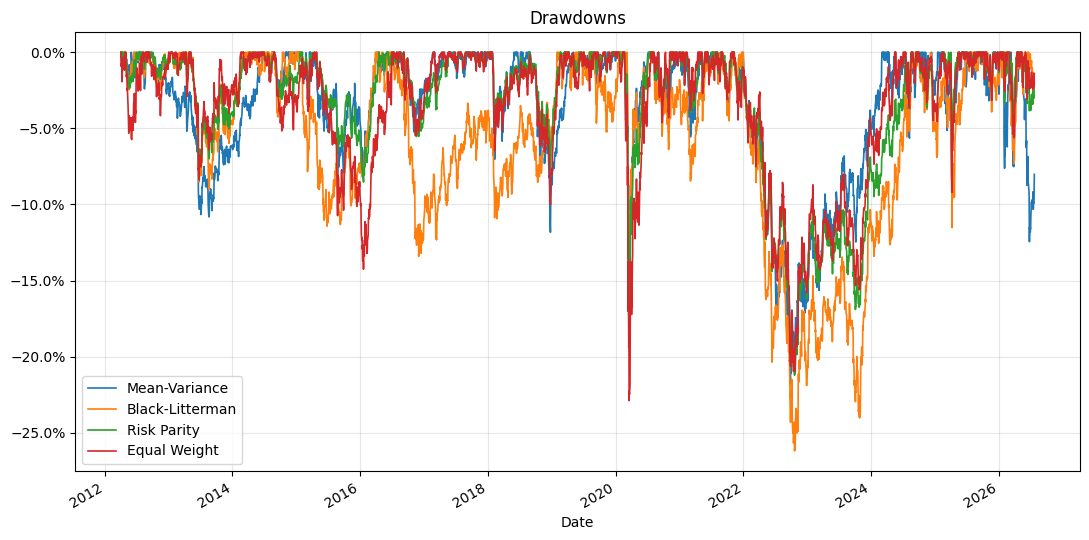

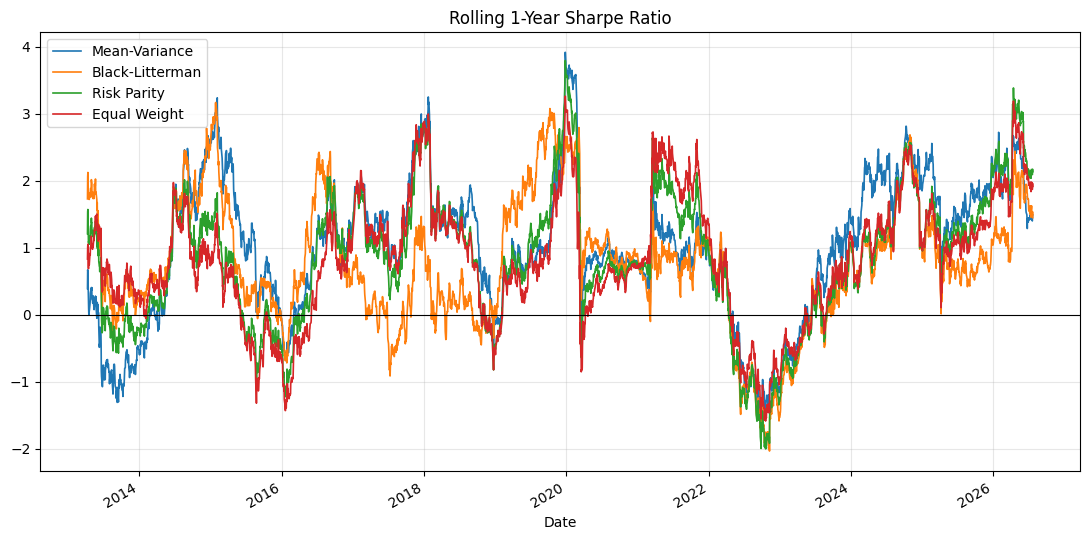

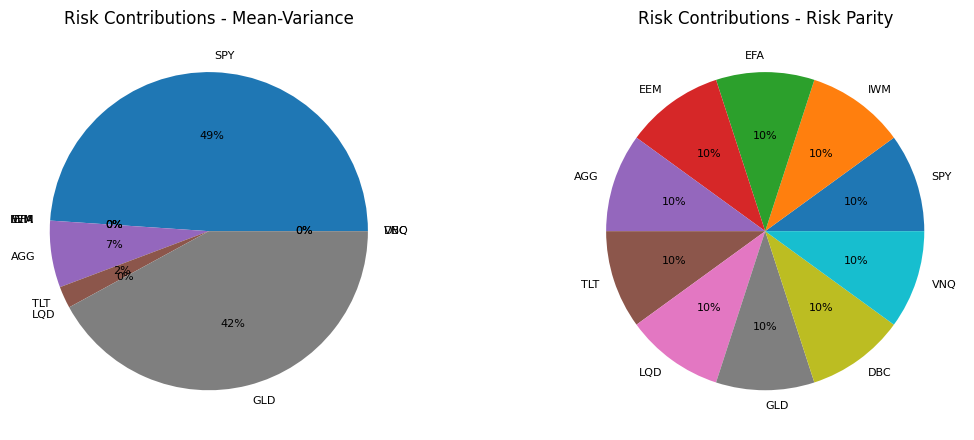

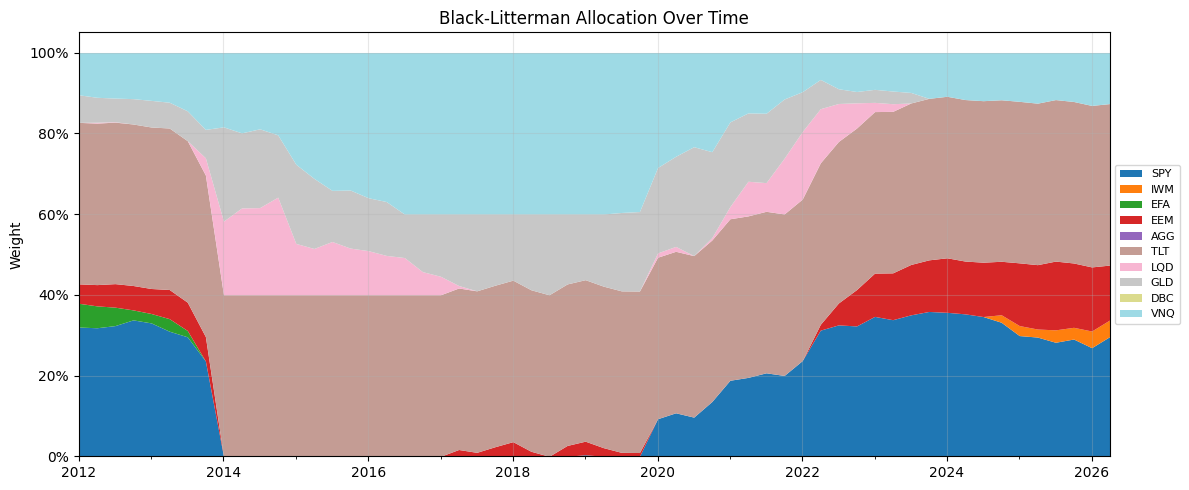

In [11]:
# ============================================================
# SECTION 11 | VISUALIZATION SUITE
# ============================================================
LABELS = {"mean_variance": "Mean-Variance", "black_litterman": "Black-Litterman",
          "risk_parity": "Risk Parity", "equal_weight": "Equal Weight"}

# --- 11.1 Efficient frontier -------------------------------------------
fig, ax = plt.subplots()
ax.plot(frontier[:, 0], frontier[:, 1], "b-", lw=2, label="Efficient Frontier")
ax.scatter(vol_full, mu_full, c="gray", s=40, zorder=3)
for t, x, y in zip(TICKERS, vol_full, mu_full):
    ax.annotate(t, (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")
for w, lbl, c in [(w_msr, "Max Sharpe", "red"), (w_gmv, "Min Vol", "green"),
                  (w_bl, "Black-Litterman", "purple"), (w_rp, "Risk Parity", "orange")]:
    r, v, _ = port_stats(w, mu_full, sigma_full)
    ax.scatter(v, r, s=140, marker="*", color=c, zorder=4, label=lbl)
ax.set_xlabel("Annualized Volatility"); ax.set_ylabel("Annualized Return")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1)); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title("Efficient Frontier & Optimal Portfolios"); ax.legend()
plt.tight_layout(); plt.show()

# --- 11.2 Allocation comparison ----------------------------------------
alloc = pd.DataFrame({"Mean-Variance": w_msr, "Black-Litterman": w_bl,
                      "Risk Parity": w_rp, "Market Cap": w_mkt}, index=TICKERS)
alloc.plot(kind="bar", figsize=(12, 5), width=0.8)
plt.title("Portfolio Weights by Method"); plt.ylabel("Weight")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.tight_layout(); plt.show()

# --- 11.3 Cumulative out-of-sample performance -------------------------
fig, ax = plt.subplots()
for s in STRATEGIES:
    (1 + results[s]).cumprod().plot(ax=ax, label=LABELS[s], lw=1.6)
ax.set_yscale("log"); ax.set_title("Out-of-Sample Growth of $1 (log scale)")
ax.set_ylabel("Portfolio Value"); ax.legend()
plt.tight_layout(); plt.show()

# --- 11.4 Drawdowns -----------------------------------------------------
fig, ax = plt.subplots()
for s in STRATEGIES:
    curve = (1 + results[s]).cumprod()
    (curve / curve.cummax() - 1).plot(ax=ax, label=LABELS[s], lw=1.2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title("Drawdowns"); ax.legend()
plt.tight_layout(); plt.show()

# --- 11.5 Rolling 1-year Sharpe ----------------------------------------
fig, ax = plt.subplots()
for s in STRATEGIES:
    r = results[s]
    roll = (r.rolling(252).mean() / r.rolling(252).std()) * np.sqrt(252)
    roll.plot(ax=ax, label=LABELS[s], lw=1.2)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Rolling 1-Year Sharpe Ratio"); ax.legend()
plt.tight_layout(); plt.show()

# --- 11.6 Risk parity: risk contribution check ------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rc_mv = risk_contributions(w_msr, sigma_full)
rc_rp = risk_contributions(w_rp, sigma_full)
axes[0].pie(rc_mv / rc_mv.sum(), labels=TICKERS, autopct="%1.0f%%", textprops={"fontsize": 8})
axes[0].set_title("Risk Contributions - Mean-Variance")
axes[1].pie(rc_rp / rc_rp.sum(), labels=TICKERS, autopct="%1.0f%%", textprops={"fontsize": 8})
axes[1].set_title("Risk Contributions - Risk Parity")
plt.tight_layout(); plt.show()

# --- 11.7 Weight evolution (Black-Litterman) ---------------------------
weight_paths["black_litterman"].plot.area(figsize=(12, 5), cmap="tab20", lw=0)
plt.title("Black-Litterman Allocation Over Time"); plt.ylabel("Weight")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout(); plt.show()

In [12]:
# ============================================================
# SECTION 12 | FINAL SUMMARY
# ============================================================
print("=" * 62)
print("PORTFOLIO OPTIMIZATION ENGINE - SUMMARY")
print("=" * 62)
print(metrics.round(3).to_string())
print("\nKey takeaways to verify against your own run:")
print(" 1. Mean-variance typically shows highest turnover and most")
print("    concentrated weights (input-sensitivity in action).")
print(" 2. Black-Litterman weights stay closer to market weights -")
print("    the equilibrium anchor is doing its job.")
print(" 3. Risk parity usually has the shallowest drawdowns but may")
print("    lag in strong equity bull markets (bond-heavy).")

PORTFOLIO OPTIMIZATION ENGINE - SUMMARY
                 Ann. Return  Ann. Vol  Sharpe  Sortino  Max Drawdown  Calmar  Daily VaR 95%  Avg Turnover/Rebal
Mean-Variance          0.086     0.099   0.715    0.878        -0.218   0.394         -0.009               0.196
Black-Litterman        0.067     0.102   0.521    0.677        -0.262   0.255         -0.010               0.073
Risk Parity            0.057     0.078   0.533    0.656        -0.212   0.268         -0.007               0.044
Equal Weight           0.067     0.100   0.536    0.672        -0.229   0.295         -0.009               0.000

Key takeaways to verify against your own run:
 1. Mean-variance typically shows highest turnover and most
    concentrated weights (input-sensitivity in action).
 2. Black-Litterman weights stay closer to market weights -
    the equilibrium anchor is doing its job.
 3. Risk parity usually has the shallowest drawdowns but may
    lag in strong equity bull markets (bond-heavy).


##My Interpretation of Results

Three things stood out from this backtest (2012-2026, quarterly rebalancing, 10bps transaction costs):

1. Mean-variance won on paper, but it's the most expensive win. It posted the best Sharpe (0.72), but with nearly 20% turnover per rebalance, roughly 4x the other strategies. My backtest only charges 10bps per trade. In a real taxable account with realistic costs, a lot of that edge would get eaten. The lesson: headline Sharpe overstates how good a strategy is if you ignore how much trading it takes to get there.

2. My aggressive Black-Litterman view backfired, and that was the most useful finding. I gave the model a high-conviction view that long-term Treasuries (TLT) would return 10%, reasoning that falling rates would push long-duration bonds up. The model did exactly what it was supposed to do: it tilted the portfolio toward TLT. But long bonds got crushed during the 2022 rate-hiking cycle, which is why Black-Litterman had the deepest drawdown of all four strategies (-26.2%) and underperformed a simple equal-weight portfolio. The model didn't fail. My view did. Black-Litterman is a machine for faithfully expressing your opinions, which means bad opinions produce bad portfolios, just in a disciplined way.

3. Risk parity delivered exactly what it promises: less pain, less gain. Lowest volatility (7.8%), shallowest max drawdown (-21.2%), lowest turnover, and also the lowest return (5.7%). For a client who can't stomach equity-style swings, that trade-off is often worth it. For a growth-oriented investor over this mostly-bullish sample period, it lagged.

Overall takeaway: no method "won" cleanly. Mean-variance had the best risk-adjusted returns but the highest implementation costs, risk parity had the smoothest ride but the lowest growth, and Black-Litterman performed exactly as well as the views I fed it. If I were allocating real money, I'd anchor closer to risk parity or equal weight and use Black-Litterman only with views I'd genuinely bet on.